In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

I0000 00:00:1785214819.564413 2874938 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785214819.564993 2874938 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785214819.611764 2874938 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785214821.181867 2874938 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
df_tain = pd.read_csv(r"../data/cleaned/train.csv")
df_test = pd.read_csv(r"../data/cleaned/test.csv")
df_val= pd.read_csv(r"../data/cleaned/val.csv")

In [3]:
df_test

,Unnamed: 0,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,9606,HAM_0000627,ISIC_0034019,nv,consensus,50.0,unknown,unknown,../data/all_image/ISIC_0034019.jpg
1,5661,HAM_0001761,ISIC_0026732,nv,follow_up,30.0,male,abdomen,../data/all_image/ISIC_0026732.jpg
2,9355,HAM_0002726,ISIC_0025473,nv,consensus,5.0,male,foot,../data/all_image/ISIC_0025473.jpg
3,7757,HAM_0003424,ISIC_0033552,nv,histo,45.0,male,back,../data/all_image/ISIC_0033552.jpg
4,2284,HAM_0004081,ISIC_0031957,mel,histo,70.0,female,lower extremity,../data/all_image/ISIC_0031957.jpg
...,...,...,...,...,...,...,...,...,...
1498,4063,HAM_0006808,ISIC_0027438,nv,follow_up,65.0,male,lower extremity,../data/all_image/ISIC_0027438.jpg
1499,9437,HAM_0002425,ISIC_0032682,nv,consensus,20.0,male,back,../data/all_image/ISIC_0032682.jpg
1500,6604,HAM_0003747,ISIC_0026582,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0026582.jpg
1501,5841,HAM_0002807,ISIC_0025050,nv,follow_up,45.0,male,trunk,../data/all_image/ISIC_0025050.jpg


In [3]:
df_val

,Unnamed: 0,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,8083,HAM_0005421,ISIC_0028060,nv,histo,75.0,male,trunk,../data/all_image/ISIC_0028060.jpg
1,4277,HAM_0007328,ISIC_0030684,nv,follow_up,50.0,male,lower extremity,../data/all_image/ISIC_0030684.jpg
2,4773,HAM_0001676,ISIC_0031587,nv,follow_up,60.0,male,upper extremity,../data/all_image/ISIC_0031587.jpg
3,7783,HAM_0007494,ISIC_0033215,nv,histo,25.0,female,face,../data/all_image/ISIC_0033215.jpg
4,3011,HAM_0001180,ISIC_0029303,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0029303.jpg
...,...,...,...,...,...,...,...,...,...
1498,7310,HAM_0003507,ISIC_0033459,nv,histo,30.0,male,lower extremity,../data/all_image/ISIC_0033459.jpg
1499,413,HAM_0005514,ISIC_0024453,bkl,histo,65.0,female,face,../data/all_image/ISIC_0024453.jpg
1500,1962,HAM_0001986,ISIC_0024999,mel,histo,50.0,male,upper extremity,../data/all_image/ISIC_0024999.jpg
1501,1053,HAM_0003982,ISIC_0030056,bkl,consensus,50.0,male,trunk,../data/all_image/ISIC_0030056.jpg


In [4]:
#encoding the label
label_encode = LabelEncoder()
df_tain["dx_encode"] = label_encode.fit_transform(df_tain["dx"])

In [5]:
df_test["dx_encode"] = label_encode.transform(df_test["dx"])

df_val["dx_encode"] = label_encode.transform(df_val["dx"])

In [ ]:
df_val[["dx","dx_encode"]]

,dx,dx_encode
0,nv,5
1,nv,5
2,nv,5
3,nv,5
4,nv,5
...,...,...
1498,nv,5
1499,bkl,2
1500,mel,4
1501,bkl,2


In [13]:
df_test

,Unnamed: 0,lesion_id,image_id,dx,dx_type,age,sex,localization,path,dx_encode
0,9606,HAM_0000627,ISIC_0034019,nv,consensus,50.0,unknown,unknown,../data/all_image/ISIC_0034019.jpg,5
1,5661,HAM_0001761,ISIC_0026732,nv,follow_up,30.0,male,abdomen,../data/all_image/ISIC_0026732.jpg,5
2,9355,HAM_0002726,ISIC_0025473,nv,consensus,5.0,male,foot,../data/all_image/ISIC_0025473.jpg,5
3,7757,HAM_0003424,ISIC_0033552,nv,histo,45.0,male,back,../data/all_image/ISIC_0033552.jpg,5
4,2284,HAM_0004081,ISIC_0031957,mel,histo,70.0,female,lower extremity,../data/all_image/ISIC_0031957.jpg,4
...,...,...,...,...,...,...,...,...,...,...
1498,4063,HAM_0006808,ISIC_0027438,nv,follow_up,65.0,male,lower extremity,../data/all_image/ISIC_0027438.jpg,5
1499,9437,HAM_0002425,ISIC_0032682,nv,consensus,20.0,male,back,../data/all_image/ISIC_0032682.jpg,5
1500,6604,HAM_0003747,ISIC_0026582,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0026582.jpg,5
1501,5841,HAM_0002807,ISIC_0025050,nv,follow_up,45.0,male,trunk,../data/all_image/ISIC_0025050.jpg,5


In [14]:
df_val

,Unnamed: 0,lesion_id,image_id,dx,dx_type,age,sex,localization,path,dx_encode
0,8083,HAM_0005421,ISIC_0028060,nv,histo,75.0,male,trunk,../data/all_image/ISIC_0028060.jpg,5
1,4277,HAM_0007328,ISIC_0030684,nv,follow_up,50.0,male,lower extremity,../data/all_image/ISIC_0030684.jpg,5
2,4773,HAM_0001676,ISIC_0031587,nv,follow_up,60.0,male,upper extremity,../data/all_image/ISIC_0031587.jpg,5
3,7783,HAM_0007494,ISIC_0033215,nv,histo,25.0,female,face,../data/all_image/ISIC_0033215.jpg,5
4,3011,HAM_0001180,ISIC_0029303,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0029303.jpg,5
...,...,...,...,...,...,...,...,...,...,...
1498,7310,HAM_0003507,ISIC_0033459,nv,histo,30.0,male,lower extremity,../data/all_image/ISIC_0033459.jpg,5
1499,413,HAM_0005514,ISIC_0024453,bkl,histo,65.0,female,face,../data/all_image/ISIC_0024453.jpg,2
1500,1962,HAM_0001986,ISIC_0024999,mel,histo,50.0,male,upper extremity,../data/all_image/ISIC_0024999.jpg,4
1501,1053,HAM_0003982,ISIC_0030056,bkl,consensus,50.0,male,trunk,../data/all_image/ISIC_0030056.jpg,2


In [7]:
#data preprocessing pipe line 
# 1 we have test train and validate date set 
# we gonna perfrom agumentation only for the train cuz agumentation used to make the model undertsand the data easily nothing much
# for this we wanna convert the pd to tensor flow data set 
#and then convert images to array 
# for model tained we only need 

In [7]:
img_size = (256,256)
batch_size = 32

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(factor=0.15, value_range=(0.0, 1.0)),
    tf.keras.layers.RandomCrop(224,224)
])

E0000 00:00:1785214910.595381 2874938 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [9]:
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [10]:
def preprocess_train(image_path, label):
    image, label = preprocess_image(image_path, label)
    image = data_augmentation(image)
    return image, label

In [11]:
def preprocess_test(image_path, label):
    image, label = preprocess_image(image_path, label)
    return image, label

In [12]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_tain["path"].values,
        df_tain["dx_encode"].values
    )
)

train_dataset = (
    train_dataset
    .map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

In [15]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_val["path"].values,
        df_val["dx_encode"].values
    )
)

val_dataset = (
    val_dataset
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)


In [16]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_test["path"].values,
        df_test["dx_encode"].values
    )
)

test_dataset = (
    test_dataset
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

In [16]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [17]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Labels:", labels.numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Labels: [5 5 5 5 5 5 5 4 5 5 5 5 5 5 5 1 5 2 5 5 4 5 6 5 5 5 2 4 4 5 1 5]


In [18]:
for images , label in train_dataset.take(1):
    print(images)
    print(label)

tf.Tensor(
[[[[1.         0.99814856 1.        ]
   [1.         0.9979696  1.        ]
   [1.         0.9999809  1.        ]
   ...
   [1.         1.         1.        ]
   [1.         1.         1.        ]
   [1.         1.         1.        ]]

  [[1.         0.9968816  1.        ]
   [1.         0.9992299  1.        ]
   [1.         1.         1.        ]
   ...
   [1.         1.         1.        ]
   [1.         1.         1.        ]
   [1.         1.         1.        ]]

  [[1.         0.9984065  1.        ]
   [1.         1.         1.        ]
   [1.         1.         1.        ]
   ...
   [1.         1.         1.        ]
   [1.         1.         1.        ]
   [1.         1.         1.        ]]

  ...

  [[1.         0.99563956 1.        ]
   [1.         0.9964762  1.        ]
   [1.         0.9946861  1.        ]
   ...
   [1.         1.         1.        ]
   [1.         1.         1.        ]
   [1.         1.         1.        ]]

  [[1.         0.9962629  1.      

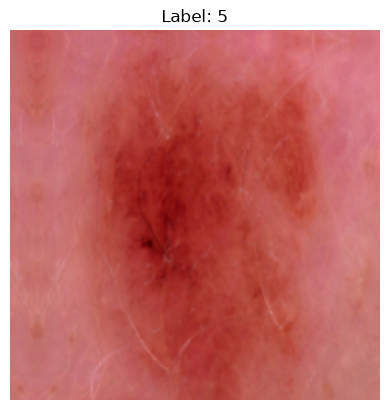

In [19]:
for image, label in train_dataset.take(1):
    plt.imshow(image[0].numpy())
    plt.title(f"Label: {label[0].numpy()}")
    plt.axis("off")
    plt.show()

In [20]:
#class weight balence

In [21]:
y_train = df_tain["dx_encode"].values


class_weights = compute_class_weight(class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train)

# Convert to dictionary
class_weight_dict = dict(enumerate(class_weights))

class_weight_dict

{0: np.float64(4.372426699937617),
 1: np.float64(2.7813492063492062),
 2: np.float64(1.3020620471855842),
 3: np.float64(12.51607142857143),
 4: np.float64(1.2853475151292866),
 5: np.float64(0.2133572798392743),
 6: np.float64(10.113997113997113)}

In [22]:
#EDA data visulaization

In [23]:
#class distribution

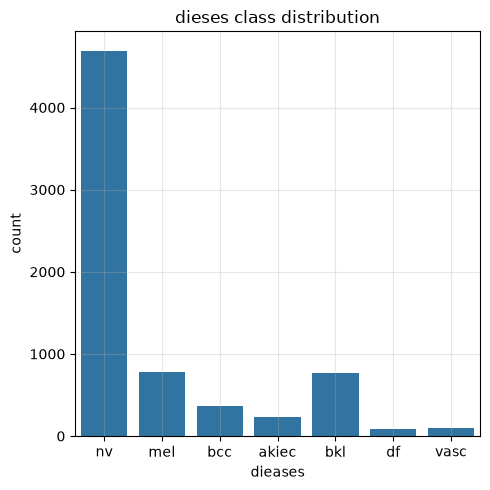

In [24]:
plt.figure(figsize=(5,5))
sns.countplot(data=df_tain,x='dx')
plt.grid(alpha=0.3)
plt.xlabel("dieases")
plt.ylabel("count")
plt.title("dieses class distribution")
plt.tight_layout()
plt.show()

In [25]:
#pixel intensity analysis

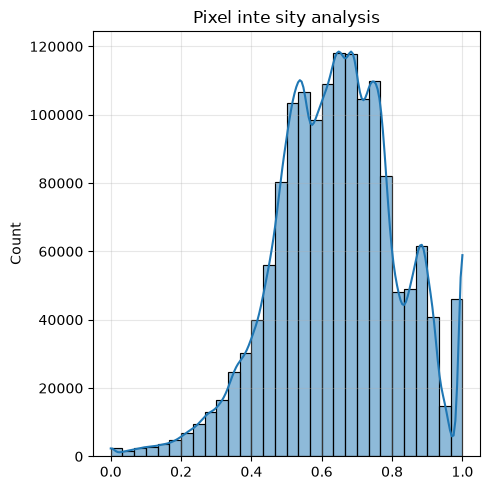

In [26]:
image , label = next(iter(train_dataset))

pixel_val = image[0:10].numpy().flatten()

plt.figure(figsize=(5,5))
sns.histplot(pixel_val,bins = 30,kde=True)
plt.title("Pixel inte sity analysis")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

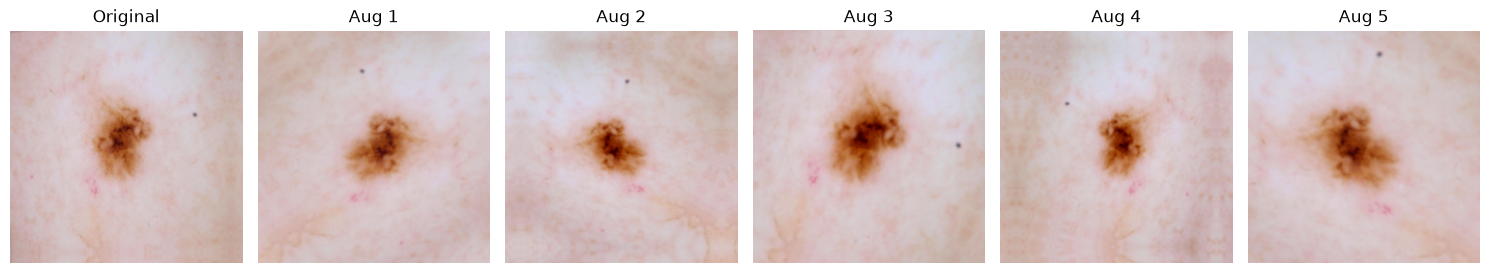

In [27]:
# Get one image from the training dataset
images, labels = next(iter(train_dataset))
image = images[0]

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

plt.figure(figsize=(15, 5))

plt.subplot(1, 6, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

for i in range(5):
    augmented = data_augmentation(image, training=True)

    plt.subplot(1, 6, i + 2)
    plt.imshow(augmented)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

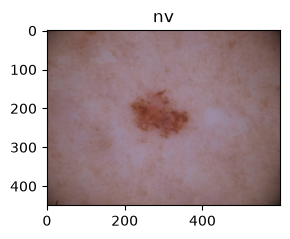

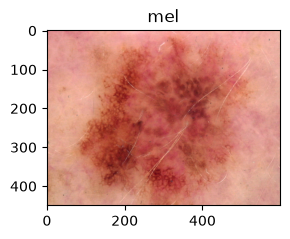

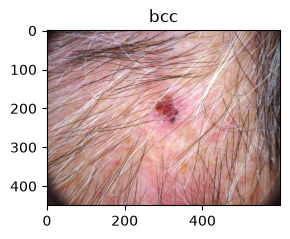

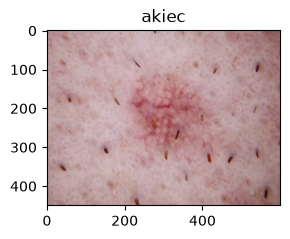

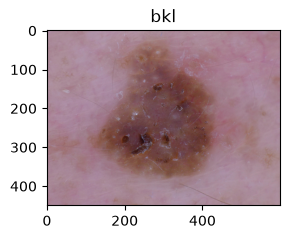

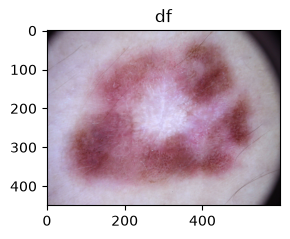

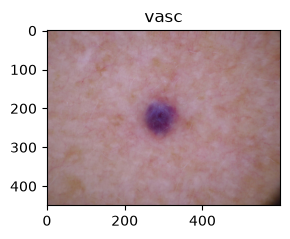

In [28]:
#class wise image charcteristic

dx= df_tain["dx"].unique()

for i in dx:
    row = df_tain[df_tain["dx"] == i]
    path = row["path"].iloc[0]
    image = cv2.imread(path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(3,3))
    plt.imshow(image_rgb)
    plt.title(i)
    plt.tight_layout()
    plt.show()

In [17]:
df_val

,Unnamed: 0,lesion_id,image_id,dx,dx_type,age,sex,localization,path,dx_encode
0,8083,HAM_0005421,ISIC_0028060,nv,histo,75.0,male,trunk,../data/all_image/ISIC_0028060.jpg,5
1,4277,HAM_0007328,ISIC_0030684,nv,follow_up,50.0,male,lower extremity,../data/all_image/ISIC_0030684.jpg,5
2,4773,HAM_0001676,ISIC_0031587,nv,follow_up,60.0,male,upper extremity,../data/all_image/ISIC_0031587.jpg,5
3,7783,HAM_0007494,ISIC_0033215,nv,histo,25.0,female,face,../data/all_image/ISIC_0033215.jpg,5
4,3011,HAM_0001180,ISIC_0029303,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0029303.jpg,5
...,...,...,...,...,...,...,...,...,...,...
1498,7310,HAM_0003507,ISIC_0033459,nv,histo,30.0,male,lower extremity,../data/all_image/ISIC_0033459.jpg,5
1499,413,HAM_0005514,ISIC_0024453,bkl,histo,65.0,female,face,../data/all_image/ISIC_0024453.jpg,2
1500,1962,HAM_0001986,ISIC_0024999,mel,histo,50.0,male,upper extremity,../data/all_image/ISIC_0024999.jpg,4
1501,1053,HAM_0003982,ISIC_0030056,bkl,consensus,50.0,male,trunk,../data/all_image/ISIC_0030056.jpg,2


In [18]:
df_test

,Unnamed: 0,lesion_id,image_id,dx,dx_type,age,sex,localization,path,dx_encode
0,9606,HAM_0000627,ISIC_0034019,nv,consensus,50.0,unknown,unknown,../data/all_image/ISIC_0034019.jpg,5
1,5661,HAM_0001761,ISIC_0026732,nv,follow_up,30.0,male,abdomen,../data/all_image/ISIC_0026732.jpg,5
2,9355,HAM_0002726,ISIC_0025473,nv,consensus,5.0,male,foot,../data/all_image/ISIC_0025473.jpg,5
3,7757,HAM_0003424,ISIC_0033552,nv,histo,45.0,male,back,../data/all_image/ISIC_0033552.jpg,5
4,2284,HAM_0004081,ISIC_0031957,mel,histo,70.0,female,lower extremity,../data/all_image/ISIC_0031957.jpg,4
...,...,...,...,...,...,...,...,...,...,...
1498,4063,HAM_0006808,ISIC_0027438,nv,follow_up,65.0,male,lower extremity,../data/all_image/ISIC_0027438.jpg,5
1499,9437,HAM_0002425,ISIC_0032682,nv,consensus,20.0,male,back,../data/all_image/ISIC_0032682.jpg,5
1500,6604,HAM_0003747,ISIC_0026582,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0026582.jpg,5
1501,5841,HAM_0002807,ISIC_0025050,nv,follow_up,45.0,male,trunk,../data/all_image/ISIC_0025050.jpg,5


In [29]:
df_tain.to_csv(r"../data/selected_col/model_train.csv",index=False)
df_test.to_csv(r"../data/selected_col/model_test.csv",index=False)
df_val.to_csv(r"../data/selected_col/model_val.csv",index=False)